In [1]:
# All required libraries are imported and a fixed random seed is set so every result is reproducible.
import random

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# A global chart style (bold labels, 150 dpi) and a color palette are applied to keep all plots uniform.
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.dpi": 150,
    }
)

PALETTE = ["#16a085", "#c0392b"]

In [3]:
# The Housing.csv dataset is loaded from Google Drive for analysis.
# 1. Load and explore the dataset

file_ids = {
    "housing": "13xDuPky-z_jInRw8VrcYN57UPtMwdhtX",
}

dataframes = {
    name: pd.read_csv(f"https://drive.google.com/uc?export=download&id={fid}")
    for name, fid in file_ids.items()
}

housing_data = dataframes["housing"]

In [4]:
# The dataset shape is printed to show how many rows and columns it has.
housing_data.shape

(545, 13)

In [5]:
# Column types and null counts are shown to reveal which features are numeric vs categorical and whether any are missing.
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
# Summary statistics are printed to understand the scale, spread and categories of each feature.
housing_data.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [7]:
# Null values are counted to confirm no missing data needs handling.
housing_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
# Duplicate rows are counted to ensure none could bias the model.
housing_data.duplicated().sum()

np.int64(0)

In [9]:
# The first few rows are displayed for a quick look at the raw values.
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


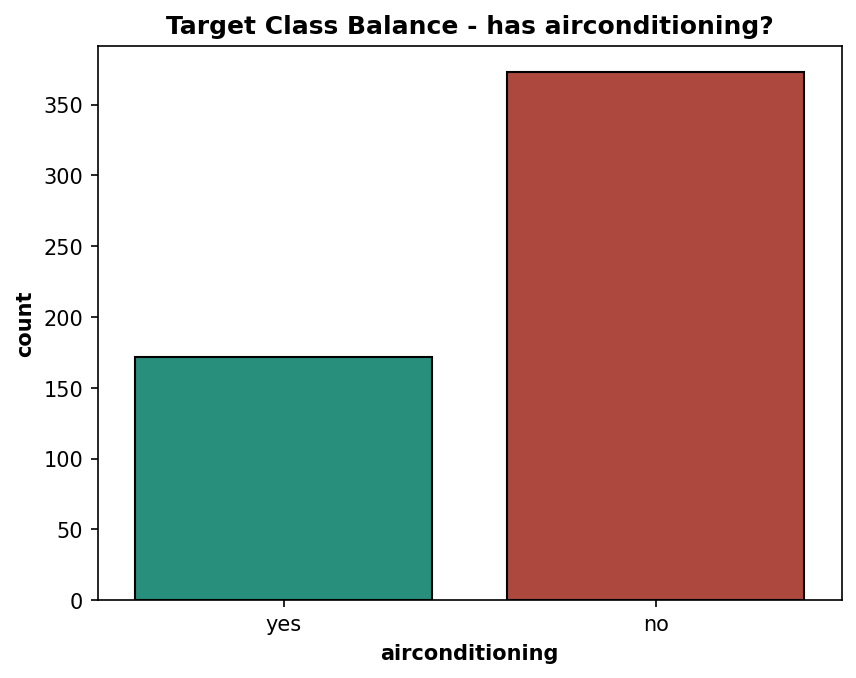

In [10]:
# The class balance of the target (airconditioning) is examined as the basis of the analysis.
# %%
sns.countplot(
    data=housing_data,
    x="airconditioning",
    hue="airconditioning",
    palette=PALETTE,
    legend=False,
    edgecolor="black",
)
plt.title("Target Class Balance - has airconditioning?")
plt.xlabel("airconditioning")
plt.ylabel("count")
plt.show()

In [11]:
# The target (airconditioning) is built once during EDA (ac_target) and reused here as y.
# 2. Separate X (features) and y (target = 'airconditioning')

X = housing_data.drop(columns="airconditioning")
y = housing_data["airconditioning"].map({"no": 0, "yes": 1})

In [12]:
# The five binary feature columns that remain in X are label-encoded to 0/1 (airconditioning is the target, so it is kept out of the feature set).
# 3. Label Encode: mainroad, guestroom, basement, hotwaterheating, prefarea, airconditioning

binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "prefarea"]

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

In [13]:
# The furnishingstatus column is one-hot encoded so its three unordered levels become usable columns.
# 4. One-Hot Encode: furnishingstatus

X = pd.get_dummies(X, columns=["furnishingstatus"], drop_first=True)

In [14]:
# The data is split 80/20 with stratification on the target so both classes stay balanced.
# 5. Train-test split (80% train, 20% test) - stratify=y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

In [15]:
# The numeric features are standardized (fit on train, transform on test) for stable model convergence.
# 6. Scale the numeric features with StandardScaler

numeric_cols = X.select_dtypes(include="number").columns.tolist()
scaler = StandardScaler()
numeric_to_scale = numeric_cols
X_train[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

In [16]:
# A LogisticRegression model is first trained on ALL features to give a baseline accuracy.
# 7. Run: train a LogisticRegression model and print the accuracy

model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_train, y_train)

cv5 = cross_val_score(model_A, X_train, y_train, cv=5, scoring="accuracy")
cv10 = cross_val_score(model_A, X_train, y_train, cv=10, scoring="accuracy")

print("=== Classification 1: ALL features (baseline) ===")
print(f"5-fold CV accuracy:  {cv5.mean():.4f} (+/- {cv5.std():.4f})")
print(f"10-fold CV accuracy: {cv10.mean():.4f} (+/- {cv10.std():.4f})")
print(f"Test accuracy:       {model_A.score(X_test, y_test):.4f}")

=== Classification 1: ALL features (baseline) ===
5-fold CV accuracy:  0.7682 (+/- 0.0386)
10-fold CV accuracy: 0.7664 (+/- 0.0657)
Test accuracy:       0.7431


In [17]:
# Ablation: dropping "area" and "basement" (added noise when predicting airconditioning).
X_train = X_train.drop(columns=["area", "basement"])
X_test = X_test.drop(columns=["area", "basement"])

In [18]:
# A LogisticRegression model is trained again on the reduced feature set to show the accuracy gain.
model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_train, y_train)

cv5 = cross_val_score(model_A, X_train, y_train, cv=5, scoring="accuracy")
cv10 = cross_val_score(model_A, X_train, y_train, cv=10, scoring="accuracy")

print("=== Classification 2: after dropping 'area' and 'basement' ===")
print(f"5-fold CV accuracy:  {cv5.mean():.4f} (+/- {cv5.std():.4f})")
print(f"10-fold CV accuracy: {cv10.mean():.4f} (+/- {cv10.std():.4f})")
print(f"Test accuracy:       {model_A.score(X_test, y_test):.4f}")

=== Classification 2: after dropping 'area' and 'basement' ===
5-fold CV accuracy:  0.7729 (+/- 0.0290)
10-fold CV accuracy: 0.7709 (+/- 0.0587)
Test accuracy:       0.7706


              precision    recall  f1-score   support

           0       0.78      0.92      0.85        75
           1       0.71      0.44      0.55        34

    accuracy                           0.77       109
   macro avg       0.75      0.68      0.70       109
weighted avg       0.76      0.77      0.75       109



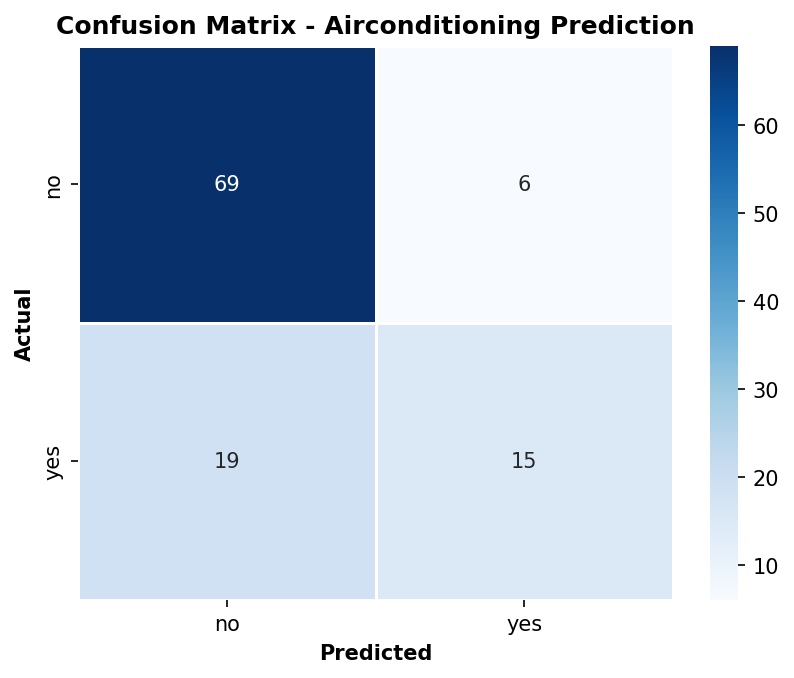

In [19]:
# Precision/recall and a confusion matrix show how often the model predicts airconditioning correctly.
y_pred = model_A.predict(X_test)
print(classification_report(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=["no", "yes"],
    yticklabels=["no", "yes"],
)
plt.title("Confusion Matrix - Airconditioning Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

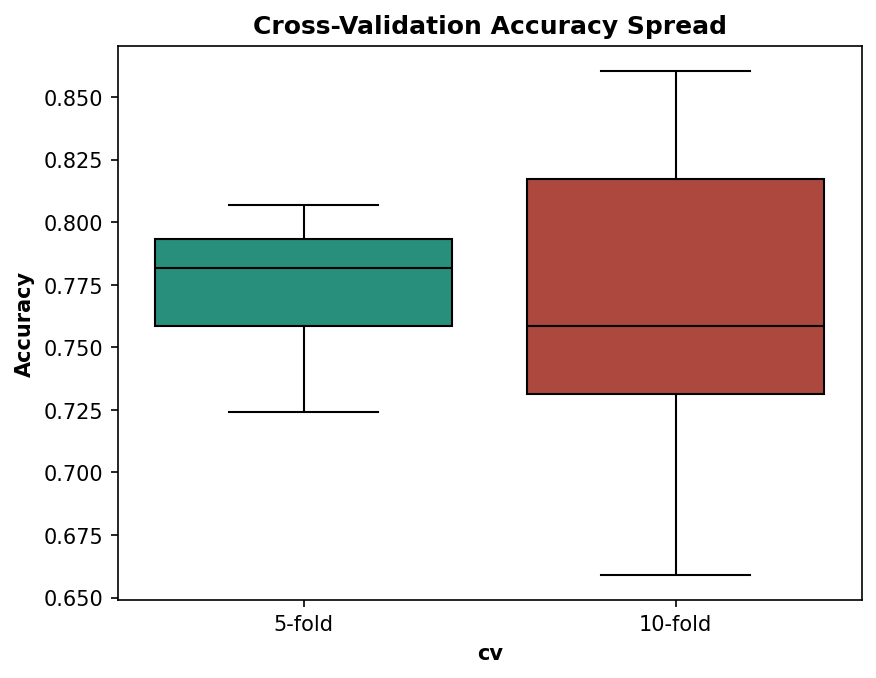

In [20]:
# The 5-fold and 10-fold cross-validation scores are compared to judge stability.
cv_long = pd.DataFrame(
    {
        "fold": list(range(1, len(cv5) + 1)) + list(range(1, len(cv10) + 1)),
        "cv": ["5-fold"] * len(cv5) + ["10-fold"] * len(cv10),
        "accuracy": list(cv5) + list(cv10),
    }
)
sns.boxplot(
    data=cv_long,
    x="cv",
    y="accuracy",
    hue="cv",
    palette=PALETTE,
    linecolor="black",
    legend=False,
)
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Spread")
plt.show()

No missing values or duplicate rows turned up in the housing dataset. Looking at the exploratory analysis, price, area, bedrooms, bathrooms, and stories — along with a few amenities — all seem tied to whether a house has air conditioning.

The Logistic Regression model started at around **74.3% test accuracy** using all features (76.8% on 5-fold CV, 76.6% on 10-fold CV). Dropping the `area` and `basement` features actually pushed this up to **77.1% test accuracy** (77.3% on 5-fold, 77.1% on 10-fold), which suggests those two features weren't adding much and may have been introducing some noise. The close CV numbers across folds also point to fairly stable performance.

That said, accuracy alone doesn't tell the whole story. The classification report shows a clear imbalance: for houses **without** air conditioning, the model does well (92% recall), but for houses that **do** have air conditioning, it only catches 44% of them — meaning it misses more than half. Part of this comes from the class split itself (75 "no AC" vs. 34 "AC" in the test set), so the model naturally leans toward predicting the majority class. So for now, it's best treated as a screening tool or a decision-support aid rather than something to base business decisions on outright — a closer look at class balance (e.g., class weighting or resampling), a bit more feature engineering, and testing a few other classification models would help before taking this further.
